# MCS Predictions with AlphaGenome FT (second_2stageig)

Load chimeric sequence library + controls from the LegNet MCS experiment,
append promoter+barcode (51bp) for AGFT compatibility, predict with
second_2stageig model, and plot.

**Venv:** `mpra_agft`

In [1]:
"""Setup: load model, define prediction helper."""
import sys, json
import numpy as np
import jax, jax.numpy as jnp
from pathlib import Path

PROJ_DIR = Path('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon')
AGFT_DIR = PROJ_DIR / 'alphagenome_FT_MPRA'
sys.path.insert(0, str(AGFT_DIR))

MCS_LIB = PROJ_DIR / 'large_scale_swap/motif_context_swap/mcs_experiment/mcs_library'
OUT_DIR = PROJ_DIR / 'large_scale_swap/motif_context_swap/mcs_experiment/mcs_results/Alphagenome_ft'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = PROJ_DIR / 'lenti_AGFT/training/results/second_2stageig/checkpoints/best_stage2'
_WEIGHTS_SUBPATH = 'huggingface/hub/models--google--alphagenome-all-folds/snapshots/a8f293a76ee73d5b57f3bf2ae146510589fcf187'
DEFAULT_WEIGHTS = Path('/grid/wsbs/home_norepl/pmantill/Liver_AGFT/.weights') / _WEIGHTS_SUBPATH

PROMOTER_SEQ = 'TCCATTATATACCCTCTAGTGTCGGTTCACGCAATG'
BARCODE = 'AGAGACTGAGGCCAC'
SUFFIX = PROMOTER_SEQ + BARCODE  # 51bp appended to 230bp = 281bp
ACGT = 'ACGT'

# Patch use_encoder_output bug
ckpt_config_path = CKPT_DIR / 'config.json'
with open(ckpt_config_path) as f:
    ckpt_cfg = json.load(f)
if not ckpt_cfg.get('use_encoder_output', False):
    ckpt_cfg['use_encoder_output'] = True
    with open(ckpt_config_path, 'w') as f:
        json.dump(ckpt_cfg, f, indent=2)
    print('Patched use_encoder_output=true')

# Register head and load model
from alphagenome_ft import load_checkpoint, HeadConfig, HeadType, register_custom_head
from alphagenome.models import dna_output
from alphagenome_research.model import dna_model
from src import EncoderMPRAHead

head_meta = ckpt_cfg.get('head_configs', {}).get('mpra_head', {}).get('metadata', {})
register_custom_head('mpra_head', EncoderMPRAHead, HeadConfig(
    type=HeadType.GENOME_TRACKS, name='mpra_head',
    output_type=dna_output.OutputType.RNA_SEQ, num_tracks=1,
    metadata=head_meta,
))

model = load_checkpoint(
    str(CKPT_DIR),
    base_checkpoint_path=str(DEFAULT_WEIGHTS) if DEFAULT_WEIGHTS.exists() else None,
    init_seq_len=281,
)
organism_enum = dna_model.Organism.HOMO_SAPIENS
print(f'Loaded model from {CKPT_DIR}')


def ohe_to_str(ohe):
    """Convert (L, 4) ACGT one-hot to string."""
    return ''.join(ACGT[np.argmax(ohe[i])] for i in range(ohe.shape[0]))


def predict_agft(ohe_batch, model, batch_size=32):
    """Predict with AGFT. Input: (N, 230, 4) ACGT numpy. Returns (N,) predictions.
    Appends promoter+barcode to each seq before encoding."""
    # Convert OHE to strings, append suffix, re-encode with model's encoder
    all_preds = []
    for i in range(0, len(ohe_batch), batch_size):
        batch_ohe = ohe_batch[i:i+batch_size]
        seqs_281 = []
        for j in range(len(batch_ohe)):
            seq_str = ohe_to_str(batch_ohe[j]) + SUFFIX
            seq_onehot = jnp.array(model._one_hot_encoder.encode(seq_str))
            seqs_281.append(seq_onehot)
        batch_seq = jnp.stack(seqs_281, axis=0)  # (B, 281, 4)
        org_idx = jnp.zeros((len(batch_ohe), 1), dtype=jnp.int32)

        with model._device_context:
            preds = model._predict(
                model._params, model._state,
                batch_seq, org_idx,
                negative_strand_mask=jnp.zeros(len(batch_ohe), dtype=bool),
                strand_reindexing=jax.device_put(
                    model._metadata[organism_enum].strand_reindexing,
                    model._device_context._device),
            )
        pred_arr = np.array(preds['mpra_head'], dtype=np.float32)
        if pred_arr.ndim == 3:
            pred_arr = pred_arr.sum(axis=1)  # pool positions
        all_preds.append(pred_arr.squeeze())
    return np.concatenate(all_preds)

Loading checkpoint from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/lenti_AGFT/training/results/second_2stageig/checkpoints/best_stage2
  Custom heads: ['mpra_head']
  Model type: Full model
Loading full model from checkpoint...
  Using local base checkpoint at: /grid/wsbs/home_norepl/pmantill/Liver_AGFT/.weights/huggingface/hub/models--google--alphagenome-all-folds/snapshots/a8f293a76ee73d5b57f3bf2ae146510589fcf187


/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/mpra_agft/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/mpra_agft/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


✓ Checkpoint loaded successfully
  Total parameters: 455,176,326
Loaded model from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/lenti_AGFT/training/results/second_2stageig/checkpoints/best_stage2


In [2]:
"""Load activity library metadata and chimera file info."""
import pandas as pd

BINS = ['high', 'mid', 'low']

# Activity bin mapping from original CSV
BASE_DIR = PROJ_DIR / 'large_scale_swap'
ACTIVITY_CSV = BASE_DIR / 'data/activity_lib/k562_activity_library.csv'
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Load LegNet predictions (for reference)
legnet_preds = np.load(MCS_LIB / 'predictions.npz')
print('LegNet prediction keys:', list(legnet_preds.keys()))

# Get annotated seq IDs from saved WT file (created by LegNet MCS notebook)
wt_check = np.load(MCS_LIB / 'wt_sequences.npz', allow_pickle=True)
annotated_ids = list(wt_check['seq_ids'])
print(f'{len(annotated_ids)} annotated sequences')

# Reconstruct sampled_seqs (same sampling as LegNet notebook for chimera indexing)
MAX_PER_BIN = 100
rng = np.random.RandomState(42)
bin_seqs = {b: [sid for sid in annotated_ids if bin_map[sid] == b] for b in BINS}
sampled_seqs = {}
for b in BINS:
    ids = bin_seqs[b]
    if len(ids) > MAX_PER_BIN:
        ids = list(rng.choice(ids, MAX_PER_BIN, replace=False))
    sampled_seqs[b] = ids
    print(f'  {b}: {len(ids)} sampled')

LegNet prediction keys: ['chimera_high_high', 'chimera_high_mid', 'chimera_high_low', 'chimera_mid_high', 'chimera_mid_mid', 'chimera_mid_low', 'chimera_low_high', 'chimera_low_mid', 'chimera_low_low', 'wt_high', 'context_high', 'context_ablated_high', 'wt_mid', 'context_mid', 'context_ablated_mid', 'wt_low', 'context_low', 'context_ablated_low']
954 annotated sequences
  high: 100 sampled
  mid: 100 sampled
  low: 100 sampled


In [3]:
"""Predict with AGFT on WT, controls, and chimeras. Saves incrementally."""

# --- Load pre-built WT and context_ablated sequences from LegNet notebook ---
wt_data = np.load(MCS_LIB / 'wt_sequences.npz', allow_pickle=True)
ca_data = np.load(MCS_LIB / 'context_ablated_sequences.npz', allow_pickle=True)

wt_seqs = wt_data['wt']              # (n_annotated, 230, 4)
wt_seq_ids = list(wt_data['seq_ids'])
ca_seqs = ca_data['context_ablated']  # (n_annotated, 50, 230, 4)
ca_seq_ids = list(ca_data['seq_ids'])

assert wt_seq_ids == ca_seq_ids, "WT and context_ablated seq_id order mismatch"
assert set(wt_seq_ids) == set(annotated_ids), "Saved seq_ids don't match annotated_ids"
print(f'Loaded WT: {wt_seqs.shape}, context_ablated: {ca_seqs.shape}')

# Build index mapping: saved order -> annotated_ids order
saved_to_idx = {sid: i for i, sid in enumerate(wt_seq_ids)}

# --- Incremental save directory ---
PARTIAL_DIR = OUT_DIR / 'partial'
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

# --- WT predictions (skip if already saved) ---
wt_path = PARTIAL_DIR / 'wt_preds.npz'
if wt_path.exists():
    _wt = np.load(wt_path, allow_pickle=True)
    wt_preds = _wt['preds']
    wt_pred_map = dict(zip(wt_seq_ids, wt_preds))
    print(f'Loaded cached WT preds: {len(wt_preds)}, mean={wt_preds.mean():.4f}')
else:
    wt_preds = predict_agft(wt_seqs, model)
    wt_pred_map = dict(zip(wt_seq_ids, wt_preds))
    np.savez_compressed(wt_path, preds=wt_preds)
    print(f'WT preds: {len(wt_preds)}, mean={wt_preds.mean():.4f} [saved]')

# --- Context-ablated controls (skip if already saved) ---
ca_path = PARTIAL_DIR / 'ca_preds.npz'
if ca_path.exists():
    _ca = np.load(ca_path, allow_pickle=True)
    ca_pred_map = dict(zip(ca_seq_ids, _ca['preds']))
    print(f'Loaded cached context_ablated preds: {len(ca_pred_map)}')
else:
    ca_pred_map = {}
    for i, sid in enumerate(ca_seq_ids):
        ca_preds_i = predict_agft(ca_seqs[i], model)  # (50,)
        ca_pred_map[sid] = float(ca_preds_i.mean())
        if (i + 1) % 100 == 0:
            print(f'  context_ablated: {i+1}/{len(ca_seq_ids)}')
    print('Done context_ablated.')
    ca_arr = np.array([ca_pred_map[sid] for sid in ca_seq_ids], dtype=np.float32)
    np.savez_compressed(ca_path, preds=ca_arr)
    print(f'  [saved]')

# --- Chimera predictions (save each combo incrementally) ---
BINS = ['high', 'mid', 'low']
chimera_preds_agft = {}
for db in BINS:
    for rb in BINS:
        combo_path = PARTIAL_DIR / f'chimera_{db}_{rb}.npy'
        fname = MCS_LIB / f'chimeras_{db}_motif_{rb}_context.npz'
        if not fname.exists():
            continue
        # Skip if already computed
        if combo_path.exists():
            chimera_preds_agft[(db, rb)] = np.load(combo_path)
            print(f'  ({db}, {rb}): loaded cached ({len(chimera_preds_agft[(db, rb)])} pairs)')
            continue
        arr = np.load(fname)['chimeras']  # (n_pairs, 50, 230, 4)
        pair_means = []
        for pi in range(arr.shape[0]):
            p = predict_agft(arr[pi], model)  # (50,)
            pair_means.append(p.mean())
            if (pi + 1) % 500 == 0:
                print(f'    ({db},{rb}): {pi+1}/{arr.shape[0]}')
        pair_means = np.array(pair_means, dtype=np.float32)
        chimera_preds_agft[(db, rb)] = pair_means
        np.save(combo_path, pair_means)
        print(f'  ({db}, {rb}): {len(pair_means)} pairs, mean={np.mean(pair_means):.4f} [saved]')

print('Done all AGFT predictions.')

# --- Final combined save ---
save_dict = {}
for (db, rb), preds in chimera_preds_agft.items():
    save_dict[f'chimera_{db}_{rb}'] = preds
for b in BINS:
    sids = [sid for sid in wt_seq_ids if bin_map[sid] == b]
    save_dict[f'wt_{b}'] = np.array([wt_pred_map[sid] for sid in sids])
    save_dict[f'context_ablated_{b}'] = np.array([ca_pred_map[sid] for sid in sids])
np.savez_compressed(OUT_DIR / 'agft_predictions.npz', **save_dict)
print(f'Saved: {OUT_DIR}/agft_predictions.npz')

Loaded WT: (954, 230, 4), context_ablated: (954, 50, 230, 4)
WT preds: 954, mean=0.0159 [saved]
  context_ablated: 100/954
  context_ablated: 200/954
  context_ablated: 300/954
  context_ablated: 400/954
  context_ablated: 500/954
  context_ablated: 600/954
  context_ablated: 700/954
  context_ablated: 800/954
  context_ablated: 900/954
Done context_ablated.
  [saved]
    (high,high): 500/9900
    (high,high): 1000/9900
    (high,high): 1500/9900
    (high,high): 2000/9900
    (high,high): 2500/9900
    (high,high): 3000/9900
    (high,high): 3500/9900
    (high,high): 4000/9900
    (high,high): 4500/9900
    (high,high): 5000/9900
    (high,high): 5500/9900
    (high,high): 6000/9900
    (high,high): 6500/9900
    (high,high): 7000/9900
    (high,high): 7500/9900
    (high,high): 8000/9900
    (high,high): 8500/9900
    (high,high): 9000/9900
    (high,high): 9500/9900
  (high, high): 9900 pairs, mean=0.6740 [saved]
    (high,mid): 500/10000
    (high,mid): 1000/10000
    (high,mid): 

high: n=222, pred range=[1.008, 2.688]
mid: n=129, pred range=[-0.250, 0.245]
low: n=139, pred range=[-1.453, -1.008]
Excluded (in gap): 464
  rebinned (high, high): 4032 pairs
  rebinned (high, low): 2624 pairs
  rebinned (high, mid): 2688 pairs
  rebinned (low, high): 2624 pairs
  rebinned (low, low): 1640 pairs
  rebinned (low, mid): 1722 pairs
  rebinned (mid, high): 2688 pairs
  rebinned (mid, low): 1722 pairs
  rebinned (mid, mid): 1722 pairs
Saved: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/mcs_experiment/mcs_results/Alphagenome_ft/motif_context_swap_alphagenome_ft.png


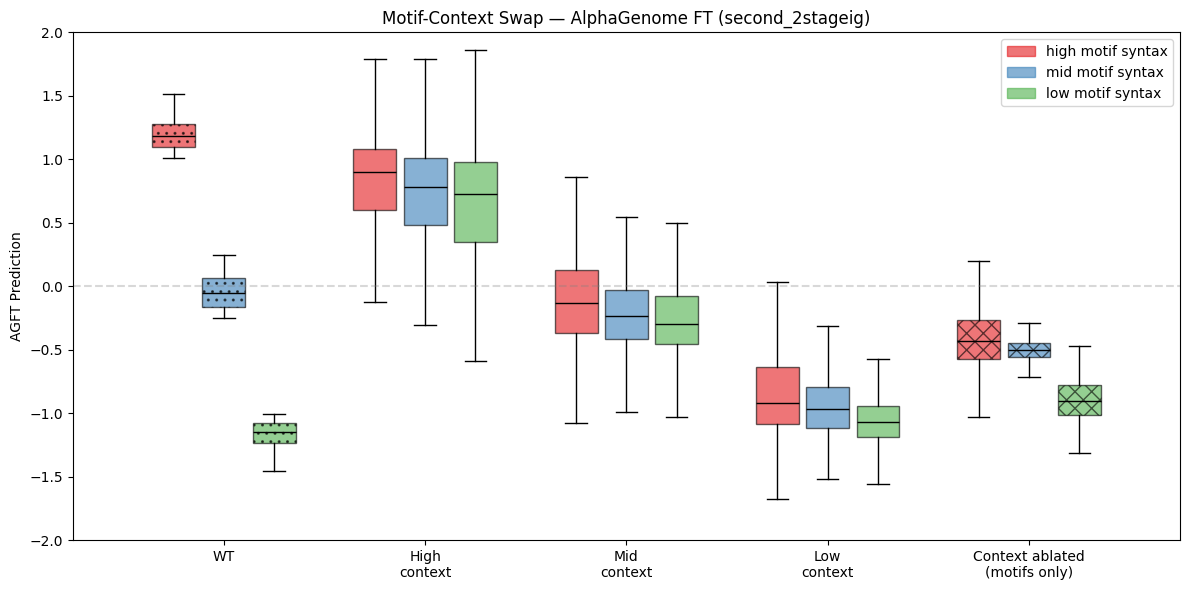

In [6]:
"""Re-bin by AGFT predicted activity and plot."""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BIN_COLORS = {'high': '#e41a1c', 'mid': '#377eb8', 'low': '#4daf4a'}

# Re-bin by AGFT WT prediction: high >1, mid (-0.5, 0.5), low <-1
pred_bin_map = {}
for sid in annotated_ids:
    p = wt_pred_map[sid]
    if p > 1:
        pred_bin_map[sid] = 'high'
    elif -0.25 <= p <= 0.25:
        pred_bin_map[sid] = 'mid'
    elif p < -1:
        pred_bin_map[sid] = 'low'

binned_ids = [sid for sid in annotated_ids if sid in pred_bin_map]
for b in BINS:
    sids = [sid for sid in binned_ids if pred_bin_map[sid] == b]
    preds = [wt_pred_map[sid] for sid in sids]
    print(f'{b}: n={len(sids)}, pred range=[{min(preds):.3f}, {max(preds):.3f}]')
print(f'Excluded (in gap): {len(annotated_ids) - len(binned_ids)}')

# Re-bin chimera predictions.
# Need sampled_seqs mapping — reload from chimera file shapes + original bin ordering.
# The chimeras were built with sampled_seqs from the LegNet notebook (MAX_PER_BIN=100).
# We need the same donor/recipient ID lists to re-index.
# Reconstruct: group annotated_ids by original bin, sample same way.
bin_seqs = {b: [sid for sid in annotated_ids if bin_map[sid] == b] for b in BINS}
MAX_PER_BIN = 100
rng = np.random.RandomState(42)
sampled_seqs = {}
for b in BINS:
    ids = bin_seqs[b]
    if len(ids) > MAX_PER_BIN:
        ids = list(rng.choice(ids, MAX_PER_BIN, replace=False))
    sampled_seqs[b] = ids

chimera_preds_rebinned = {}
for (orig_db, orig_rb), pair_means in chimera_preds_agft.items():
    if len(pair_means) == 0:
        continue
    donor_ids = sampled_seqs[orig_db]
    recip_ids = sampled_seqs[orig_rb]
    pair_idx = 0
    for donor_id in donor_ids:
        for recip_id in recip_ids:
            if donor_id == recip_id:
                continue
            if donor_id in pred_bin_map and recip_id in pred_bin_map:
                key = (pred_bin_map[donor_id], pred_bin_map[recip_id])
                chimera_preds_rebinned.setdefault(key, []).append(pair_means[pair_idx])
            pair_idx += 1

for key in sorted(chimera_preds_rebinned):
    chimera_preds_rebinned[key] = np.array(chimera_preds_rebinned[key], dtype=np.float32)
    print(f'  rebinned ({key[0]}, {key[1]}): {len(chimera_preds_rebinned[key])} pairs')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x_labels = ['WT', 'High\ncontext', 'Mid\ncontext', 'Low\ncontext',
            'Context ablated\n(motifs only)']
n_conditions = len(x_labels)
WT_IDX, CA_IDX = 0, 4
width = 0.25
offsets = {'high': -width, 'mid': 0, 'low': width}

for motif_bin in BINS:
    data = []
    sids = [sid for sid in binned_ids if pred_bin_map[sid] == motif_bin]

    data.append([wt_pred_map[sid] for sid in sids])
    for ctx_bin in BINS:
        key = (motif_bin, ctx_bin)
        if key in chimera_preds_rebinned and len(chimera_preds_rebinned[key]) > 0:
            data.append(chimera_preds_rebinned[key].tolist())
        else:
            data.append([])
    data.append([ca_pred_map[sid] for sid in sids])

    positions = [i + offsets[motif_bin] for i in range(n_conditions)]
    bp = ax.boxplot(data, positions=positions, widths=width * 0.85,
                    patch_artist=True, showfliers=False, medianprops=dict(color='black'))
    for ci, patch in enumerate(bp['boxes']):
        patch.set_facecolor(BIN_COLORS[motif_bin])
        patch.set_alpha(0.6)
        if ci == WT_IDX:
            patch.set_hatch('..')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
        elif ci == CA_IDX:
            patch.set_hatch('xx')
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)

ax.set_xticks(range(n_conditions))
ax.set_xticklabels(x_labels)
ax.set_ylabel('AGFT Prediction')
ax.set_title('Motif-Context Swap — AlphaGenome FT (second_2stageig)')
ax.set_ylim(-2,2)

handles = [mpatches.Patch(color=BIN_COLORS[b], alpha=0.6, label=f'{b} motif syntax') for b in BINS]
ax.legend(handles=handles, loc='upper right')
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.3)

fig.tight_layout()
#plt.show()

fig.savefig(OUT_DIR / 'motif_context_swap_alphagenome_ft.png', dpi=150, bbox_inches='tight')
print(f'Saved: {OUT_DIR}/motif_context_swap_alphagenome_ft.png')